In [1]:
!pip install -qq pykalman

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.5/151.5 kB 7.8 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

import warnings
warnings.filterwarnings("ignore")

data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2021-01-01",
    auto_adjust=False,
    progress=False,
    threads=False,
)
display(data.sample(15))

prices = data["Close"]
display(prices.sample(15))

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-07-27,91.968224,94.809998,94.904999,93.480003,93.709999,121214000
2020-02-13,78.570473,81.217499,81.555000,80.837502,81.047501,94747600
2020-05-21,76.838234,79.212502,80.222504,78.967499,79.665001,102688800
2020-07-07,90.379837,93.172501,94.654999,93.057503,93.852501,112424400
2020-08-25,121.301910,124.824997,125.180000,123.052498,124.697502,211495600
2020-08-05,106.763580,110.062500,110.392502,108.897499,109.377502,121776800
2020-01-22,76.654480,79.425003,79.997498,79.327499,79.644997,101832400
2020-07-21,94.092613,97.000000,99.250000,96.742500,99.172501,103433200


Ticker,AAPL
Date,
2020-04-21,67.092499
2020-09-22,111.809998
2020-12-15,127.879997
2020-03-19,61.195000
2020-06-23,91.632500
2020-10-30,108.860001
2020-09-11,112.000000
2020-11-16,120.300003
2020-09-18,106.839996


In [3]:
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=prices.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

state_means, _ = kf.filter(prices.values)
kalman_series = pd.Series(state_means.flatten(), index=prices.index)
ma30 = prices.rolling(30).mean()

display(kalman_series)

,0
Date,
2020-01-02,75.087502
2020-01-03,74.840944
2020-01-06,74.869082
2020-01-07,74.811679
2020-01-08,74.990356
...,...
2020-12-24,125.566397
2020-12-28,126.624529
2020-12-29,127.408879


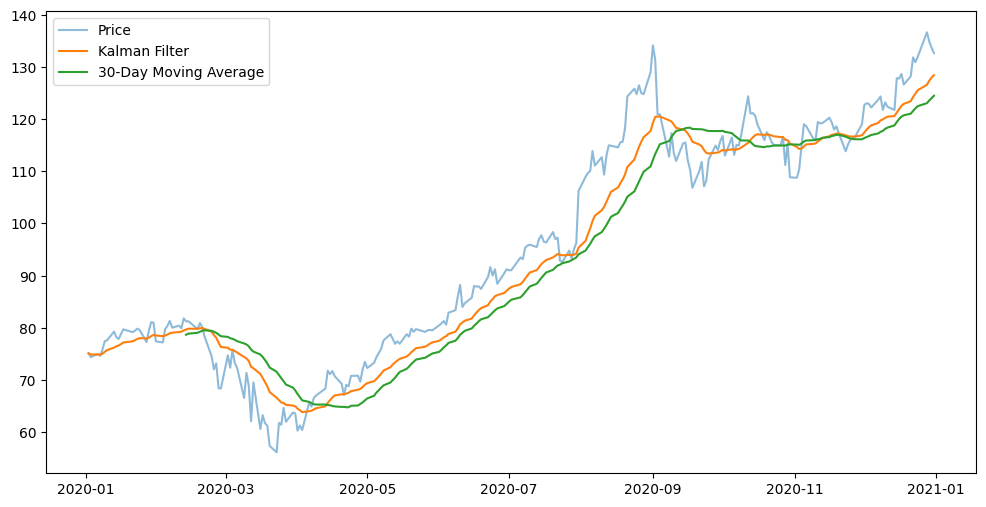

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(prices, label="Price", alpha=0.5)
plt.plot(kalman_series, label="Kalman Filter")
plt.plot(ma30, label="30-Day Moving Average")
plt.legend()
plt.show()